In [1]:
from cs336_basics.tokenization import *
from collections import defaultdict
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import numpy as np
import os

input_path = os.environ.get("DATA_DIR", "data") + "/owt_train.txt"
PAT = r"""'(?:[sdmt]|ll|ve|re)| ?\p{L}+| ?\p{N}+| ?[^\s\p{L}\p{N}]+|\s+(?!\S)|\s+"""
special_tokens = ["<|endoftext|>"]

CHUNK = 8 * 1024 * 1024
OVERLAP = 4096
file_size = os.path.getsize(input_path)

pre_tokens = defaultdict(int)
carry = ""
with open(input_path, "r", encoding="utf-8") as f:
    pbar = tqdm(total=file_size, unit="B", unit_scale=True, desc="Pre-tokenization")
    while True:
        chunk = f.read(CHUNK)
        if not chunk:
            break
        pbar.update(len(chunk.encode("utf-8")))
        buf = carry + chunk
        if len(buf) <= OVERLAP:
            carry = buf
            continue
        pre_tokens = pre_tokenization(buf[:-OVERLAP], PAT, special_tokens, pre_tokens)
        carry = buf[-OVERLAP:]
    pbar.close()
if carry:
    pre_tokens = pre_tokenization(carry, PAT, special_tokens, pre_tokens)

print(f"{len(pre_tokens)} unique pre-tokens")

Pre-tokenization:   0%|          | 0.00/11.9G [00:00<?, ?B/s]

6602016 unique pre-tokens


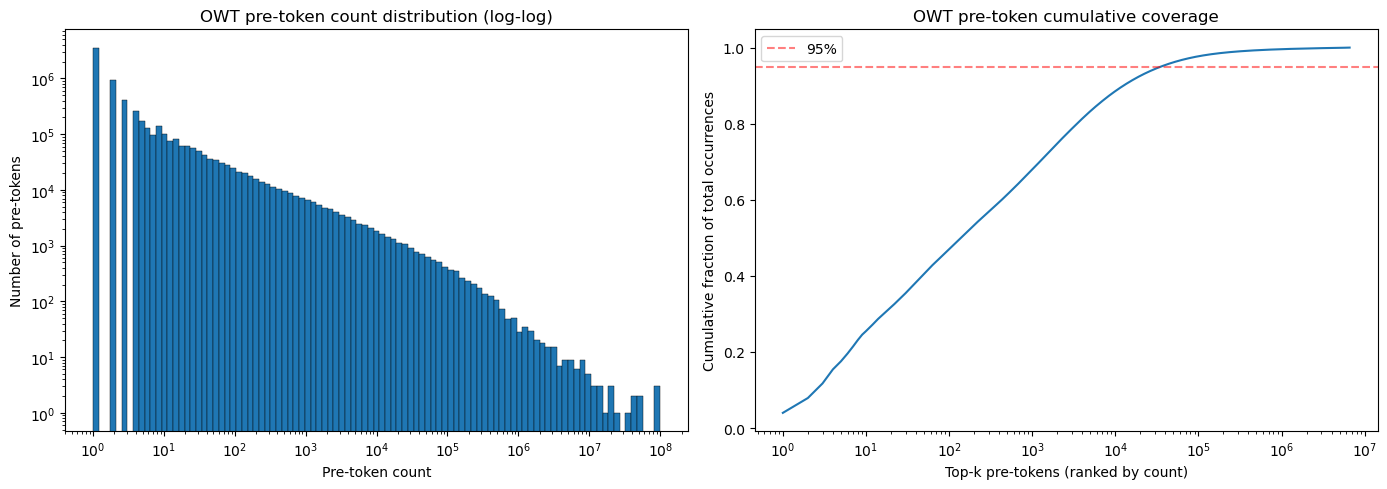

Total unique: 6,602,016
Total occurrences: 2,471,754,214
Max count: 98,599,916
Median count: 1
Mean count: 374.4
Top-35,327 pre-tokens cover 95% of occurrences


In [7]:
counts = np.array(list(pre_tokens.values()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# log-scale histogram
axes[0].hist(counts, bins=np.logspace(0, np.log10(counts.max()), 100), edgecolor="black", linewidth=0.3)
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel("Pre-token count")
axes[0].set_ylabel("Number of pre-tokens")
axes[0].set_title("OWT pre-token count distribution (log-log)")

# CDF
sorted_counts = np.sort(counts)[::-1]
cdf = np.cumsum(sorted_counts) / sorted_counts.sum()
axes[1].plot(np.arange(1, len(cdf) + 1), cdf)
axes[1].set_xscale("log")
axes[1].set_xlabel("Top-k pre-tokens (ranked by count)")
axes[1].set_ylabel("Cumulative fraction of total occurrences")
axes[1].set_title("OWT pre-token cumulative coverage")
axes[1].axhline(0.95, color="r", linestyle="--", alpha=0.5, label="95%")
axes[1].legend()

plt.tight_layout()
plt.show()

# stats
print(f"Total unique: {len(counts):,}")
print(f"Total occurrences: {counts.sum():,}")
print(f"Max count: {counts.max():,}")
print(f"Median count: {int(np.median(counts)):,}")
print(f"Mean count: {counts.mean():,.1f}")
top95 = np.searchsorted(cdf, 0.95) + 1
print(f"Top-{top95:,} pre-tokens cover 95% of occurrences")